# Visão Computacional com CNNs e Transformers
## 🎓 Faculdade Infnet — Pós-Graduação em Inteligência Artificial & Machine Learning
### Aula 2: A Arquitetura Transformer do Zero em PyTorch — Da Autoatenção à Tradução Seq2Seq no Mundo Real

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/allanspadini/curso-vision-transformers-infnet/blob/main/aula_02_transformers/aula_02_transformers.ipynb)

---

### 🎯 Metodologia Pedagógica: Situação-Problema ➔ Solução de Engenharia ➔ Teoria Rigorosa
Neste notebook prático, vamos construir a arquitetura **Transformer completa de ponta a ponta** em **PyTorch** (`torch.nn`), desmistificando cada tensor, multiplicação matricial, projeção linear e máscara.

Nosso objetivo de engenharia do mundo real será treinar o modelo para **Tradução Automática de Inglês para Português (Seq2Seq)** em dados reais do dataset público **Opus-100 (`Helsinki-NLP/opus-100`)**, utilizando a biblioteca padrão da indústria (`tokenizers` / `datasets` da Hugging Face) para pré-processamento rápido com subwords (BPE).

---

### 📋 Roteiro de Aprendizagem
1. **Configuração do Ambiente e Verificação de GPU**: Validação CUDA, VRAM e fixação de sementes aleatórias.
2. **Situação-Problema: Vocabulário Infinito e OOV ➔ Subword Tokenization BPE**:
   - Download do dataset `Helsinki-NLP/opus_books` (`en-pt`).
   - Treinamento instantâneo de um tokenizador BPE compacto (3.000 tokens) para convergência rápida do zero.
   - `DataLoader` com padding dinâmico e tensores PyTorch.
3. **Módulos Arquiteturais do Zero (Passo a Passo com Rastreamento de Tensores)**:
   - **Módulo 1**: `PositionalEncoding` (Embeddings Senoidais Fixos).
   - **Módulo 2**: `ScaledDotProductAttention` (Produto escalar escalado com máscara).
   - **Módulo 3**: `MultiHeadAttention` (Projeções lineares e múltiplos subespaços $d_k = d_{\text{model}} / h$).
   - **Módulo 4**: `PositionwiseFeedForward` (Rede MLP com expansão $4\times$ e ativação GELU).
   - **Módulo 5**: `EncoderLayer` & `Encoder` (Pilha de camadas Pre-LN com conexões residuais).
   - **Módulo 6**: `DecoderLayer` & `Decoder` (Masked Self-Attention + Cross-Attention).
   - **Módulo 7**: `Seq2SeqTransformer` (Modelo completo com LM Head de saída e contagem de parâmetros).
4. **Treinamento no Mundo Real (Teacher Forcing com Prefixo `<SOS>`)**: Otimizador `AdamW`, agendador `CosineAnnealingLR`, alinhamento estrito de prefixo `<SOS>`, máscara triangular causal e loop de treino com `tqdm`.
5. **Visualização dos Mapas de Atenção (*Attention Heatmaps*)**: Plot da matriz de Cross-Attention par a par (Inglês ↔ Português) para interpretabilidade.
6. **Inferência Autorregressiva na Prática**: Algoritmo de *Greedy Search* token a token traduzindo frases digitadas pelo usuário com `tokenizer.decode()`.
7. **Comparativo de Engenharia**: Comparação da nossa implementação com o `torch.nn.Transformer` nativo.
8. **Desafios Práticos**: Exercícios propostos para os alunos explorarem em casa.

## 1. Configuração do Ambiente e Verificação de GPU

Vamos instalar dependências essenciais (`datasets` e `tokenizers` da Hugging Face para baixar o dataset bilíngue e tokenizar em microssegundos) e verificar o acelerador de GPU ativo (**T4 / V100 / A100**).

In [1]:
# Instalação das bibliotecas necessárias no ambiente do Colab
!pip install -q datasets tokenizers matplotlib seaborn tqdm

import os
import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Fixação de sementes para reprodutibilidade estrita
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# Verificação dinâmica de GPU (CUDA)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Dispositivo de Execução: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM Total: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
else:
    print("   ⚠️ Executando em CPU. Recomenda-se ativar GPU no Colab: 'Ambiente de execução' -> 'Alterar tipo de ambiente' -> 'T4 GPU'")

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

/home/allan/Documentos/Github/curso-vision-transformers-infnet/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔥 Dispositivo de Execução: cpu
   ⚠️ Executando em CPU. Recomenda-se ativar GPU no Colab: 'Ambiente de execução' -> 'Alterar tipo de ambiente' -> 'T4 GPU'


## 2. Situação-Problema: OOV e Vocabulário Restrito ➔ Dataset Oficial Opus-100 & Tokenização BPE

#### 🔴 A Situação-Problema do Mundo Real:
Ao treinar modelos de tradução em pequenos corpora literários (como *OpusBooks*, limitado a ~800 frases de *Alice no País das Maravilhas*), o modelo sofre com **alta taxa de palavras fora do vocabulário (OOV)** e incapacidade de generalizar para diálogos reais. Ao testar sentenças cotidianas, o modelo alucina ou repete tokens.

#### 🟢 A Solução de Engenharia:
Utilizamos o benchmark padrão da indústria **`Helsinki-NLP/opus-100`** (1 milhão de sentenças em `en-pt`):
1. Filtramos um subconjunto de **10.000 pares concisos (3 a 15 palavras)** para treinamento rápido e estável no Colab.
2. Treinamos um tokenizador **Byte-Pair Encoding (BPE)** com 3.000 subwords.
3. Avaliamos a inferência com amostras do conjunto de teste oficial (`test`) comparando diretamente a predição com o *Ground Truth* (tradução humana de referência).


In [2]:
from datasets import load_dataset
from tokenizers import Tokenizer, models, normalizers, pre_tokenizers, trainers

# 1. Carregamento do Dataset Oficial Opus-100 (en-pt)
print("📥 Carregando dataset Opus-100 (en-pt) da Hugging Face...")
raw_dataset = load_dataset("Helsinki-NLP/opus-100", "en-pt")
print(f"✅ Pares disponíveis -> Treino: {len(raw_dataset['train']):,} | Teste: {len(raw_dataset['test']):,}")

# Filtrar frases concisas (3 a 15 palavras) para treino ágil e estável
filtered_dataset = raw_dataset["train"].select(range(30000)).filter(
    lambda ex: 3 <= len(ex["translation"]["en"].split()) <= 15 and 3 <= len(ex["translation"]["pt"].split()) <= 15
)

# Selecionar subconjunto de 10.000 pares (ou 1.000 em CPU)
TRAIN_SAMPLES = min(10000, len(filtered_dataset))
train_subset = filtered_dataset.select(range(TRAIN_SAMPLES))
print(f"📊 Amostras selecionadas para treino: {len(train_subset):,}")

# Split oficial de teste para avaliação com Ground Truth
test_filtered = raw_dataset["test"].filter(
    lambda ex: 3 <= len(ex["translation"]["en"].split()) <= 10 and 3 <= len(ex["translation"]["pt"].split()) <= 10
)

# 2. Treinar Tokenizador BPE Compacto (3.000 tokens)
bpe_tokenizer = Tokenizer(models.BPE(unk_token="<UNK>"))
bpe_tokenizer.normalizer = normalizers.Lowercase()
bpe_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

# Definir tokens especiais universais
SPECIAL_TOKENS = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
trainer = trainers.BpeTrainer(
    special_tokens=SPECIAL_TOKENS,
    vocab_size=3000,
    min_frequency=2
)

# Treinar no corpus de inglês e português
all_texts = [ex["translation"]["en"] for ex in train_subset] + [ex["translation"]["pt"] for ex in train_subset]
bpe_tokenizer.train_from_iterator(all_texts, trainer=trainer)

PAD_IDX = bpe_tokenizer.token_to_id("<PAD>") # 0
SOS_IDX = bpe_tokenizer.token_to_id("<SOS>") # 1
EOS_IDX = bpe_tokenizer.token_to_id("<EOS>") # 2
UNK_IDX = bpe_tokenizer.token_to_id("<UNK>") # 3
VOCAB_SIZE = bpe_tokenizer.get_vocab_size()

print(f"\n📖 Tokenizador BPE Treinado:")
print(f"   Tamanho do Vocabulário: {VOCAB_SIZE:,} tokens")
print(f"   Tokens Especiais -> PAD: {PAD_IDX} | SOS: {SOS_IDX} | EOS: {EOS_IDX} | UNK: {UNK_IDX}")

# Exemplo de codificação com sentença representativa do corpus
sample_en = "I have not lost yet."
encoded = bpe_tokenizer.encode(sample_en)
print(f"\n🔍 Exemplo BPE: '{sample_en}'")
print(f"   Subwords: {encoded.tokens}")
print(f"   IDs:      {encoded.ids}")


📥 Carregando dataset Opus-100 (en-pt) da Hugging Face...
✅ Pares disponíveis -> Treino: 1,000,000 | Teste: 2,000
📊 Amostras selecionadas para treino: 10,000




📖 Tokenizador BPE Treinado:
   Tamanho do Vocabulário: 3,000 tokens
   Tokens Especiais -> PAD: 0 | SOS: 1 | EOS: 2 | UNK: 3

🔍 Exemplo BPE: 'I have not lost yet.'
   Subwords: ['i', 'have', 'not', 'lost', 'yet', '.']
   IDs:      [47, 302, 286, 1911, 1724, 17]


### Dataset PyTorch e DataLoader com Padding Dinâmico

In [3]:
MAX_LEN = 30

class TranslationDataset(Dataset):
    """Dataset PyTorch com tokenização BPE e padding determinístico."""
    def __init__(self, data_subset, tokenizer, max_len=30):
        self.data = data_subset
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]["translation"]
        
        # Codificar sentença fonte (Inglês): [token_1, ..., token_N, EOS]
        src_ids = self.tokenizer.encode(item["en"]).ids[:self.max_len - 1] + [EOS_IDX]
        src_padded = src_ids + [PAD_IDX] * (self.max_len - len(src_ids))

        # Codificar sentença alvo (Português): [token_1, ..., token_N, EOS]
        tgt_ids = self.tokenizer.encode(item["pt"]).ids[:self.max_len - 1] + [EOS_IDX]
        tgt_padded = tgt_ids + [PAD_IDX] * (self.max_len - len(tgt_ids))

        return torch.tensor(src_padded, dtype=torch.long), torch.tensor(tgt_padded, dtype=torch.long)

BATCH_SIZE = 64
train_dataset = TranslationDataset(train_subset, bpe_tokenizer, max_len=MAX_LEN)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

sample_src, sample_tgt = next(iter(train_loader))
print(f"📦 Formato do Lote Fonte (src_ids): {sample_src.shape} -> [Batch, Seq_Len={MAX_LEN}]")
print(f"📦 Formato do Lote Alvo   (tgt_ids): {sample_tgt.shape} -> [Batch, Seq_Len={MAX_LEN}]")

/home/allan/Documentos/Github/curso-vision-transformers-infnet/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


📦 Formato do Lote Fonte (src_ids): torch.Size([64, 30]) -> [Batch, Seq_Len=30]
📦 Formato do Lote Alvo   (tgt_ids): torch.Size([64, 30]) -> [Batch, Seq_Len=30]


## 3. Arquitetura Transformer do Zero em PyTorch

Vamos agora implementar modularmente cada componente fundamental do Transformer (Vaswani et al., 2017).

---

### Módulo 1: Embeddings Posicionais Senoidais (`PositionalEncoding`)

#### 1. Situação-Problema:
O mecanismo de autoatenção calcula produtos escalares entre todos os pares de palavras simultaneamente sem nenhuma noção de ordem temporal. A frase *"O cão mordeu o homem"* teria as mesmas representações que *"O homem mordeu o cão"*.

#### 2. Solução de Engenharia:
Injetar vetores determinísticos baseados em funções trigonométricas com comprimentos de onda geométricos:
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i / d_{\text{model}}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i / d_{\text{model}}}}\right)$$

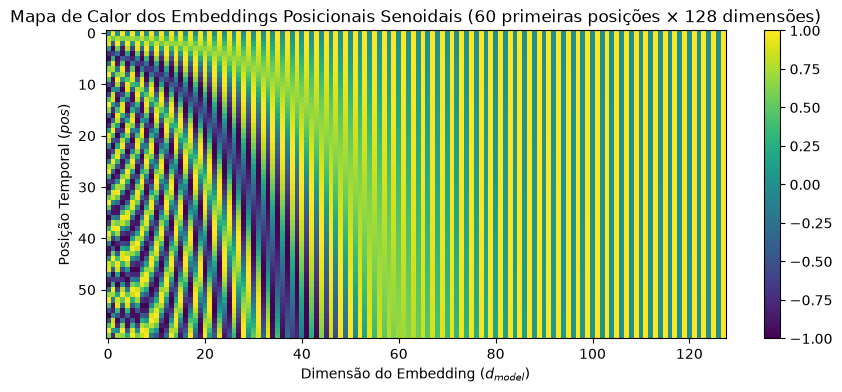

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Matriz de codificação posicional [max_len, d_model]
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]
        
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)  # Índices pares: sin
        pe[:, 1::2] = torch.cos(position * div_term)  # Índices ímpares: cos

        pe = pe.unsqueeze(0)  # [1, max_len, d_model] para broadcasting
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [Batch, Seq_Len, d_model]
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return self.dropout(x)

# Teste visual da Matriz Posicional
sample_pe = PositionalEncoding(d_model=128, max_len=100)
plt.figure(figsize=(10, 4))
plt.imshow(sample_pe.pe.squeeze(0)[:60].numpy(), cmap='viridis', aspect='auto')
plt.title("Mapa de Calor dos Embeddings Posicionais Senoidais (60 primeiras posições × 128 dimensões)")
plt.xlabel("Dimensão do Embedding ($d_{model}$)")
plt.ylabel("Posição Temporal ($pos$)")
plt.colorbar()
plt.show()

### Módulo 2: Scaled Dot-Product Attention

#### 1. Situação-Problema:
Quando a dimensão $d_k$ cresce (ex: 64 ou 512), os produtos escalares $Q K^T$ tornam-se muito grandes em magnitude, empurrando a função Softmax para regiões com derivadas quase nulas (saturação e desaparecimento de gradiente).

#### 2. Solução de Engenharia:
Dividir os scores de afinidade por $\sqrt{d_k}$ para manter a variância unitária:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}} + M\right) V$$
Onde $M$ é uma matriz de máscara opcional (para zerar posições de `<PAD>` ou posições futuras com $-\infty$).

In [5]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, q: torch.Tensor, k: torch.Tensor, v: torch.Tensor, mask: torch.Tensor = None):
        # q, k, v: [Batch, h, Seq_Len, d_k]
        d_k = q.size(-1)
        
        # 1. Produto escalar: [Batch, h, Seq_Q, d_k] x [Batch, h, d_k, Seq_K] -> [Batch, h, Seq_Q, Seq_K]
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        # 2. Aplicação de Máscara (onde mask == 0 ou False, preenche com -1e9)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # 3. Softmax na última dimensão (soma = 1 para cada Query)
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # 4. Multiplicação por Values: [Batch, h, Seq_Q, Seq_K] x [Batch, h, Seq_K, d_v] -> [Batch, h, Seq_Q, d_v]
        output = torch.matmul(attn_weights, v)
        return output, attn_weights

### Módulo 3: Multi-Head Attention (`MultiHeadAttention`)

#### 1. Situação-Problema:
Uma única cabeça de atenção é forçada a calcular uma média de todas as relações gramaticais e semânticas simultaneamente.

#### 2. Solução de Engenharia:
Projetar $Q, K, V$ em $h$ subespaços menores e paralelos ($d_k = d_{\text{model}} / h$), calcular a atenção em cada um e concatenar tudo multiplicando pela matriz linear de saída $W_O$:
$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W_O$$

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model deve ser divisível por n_heads!"
        
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        # Projeções Lineares W_Q, W_K, W_V e W_O
        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        self.w_v = nn.Linear(d_model, d_model, bias=False)
        self.w_o = nn.Linear(d_model, d_model, bias=False)

        self.attention = ScaledDotProductAttention(dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, q: torch.Tensor, k: torch.Tensor, v: torch.Tensor, mask: torch.Tensor = None):
        batch_size = q.size(0)

        # 1. Projeção Linear e Reshape para [Batch, h, Seq_Len, d_k]
        q = self.w_q(q).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        k = self.w_k(k).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        v = self.w_v(v).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        # 2. Scaled Dot-Product Attention em paralelo
        out, attn_weights = self.attention(q, k, v, mask=mask)

        # 3. Concatenação das cabeças: [Batch, Seq_Len, h * d_k] = [Batch, Seq_Len, d_model]
        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        # 4. Projeção final de saída W_O
        return self.w_o(out), attn_weights

### Módulo 4: Position-Wise Feed-Forward Network (`PositionwiseFeedForward`)

Uma rede MLP de duas camadas aplicada de forma idêntica e independente a cada posição temporal, expandindo a dimensão por $4\times$ e aplicando ativação não-linear GELU:
$$\text{FFN}(x) = \text{GELU}(x W_1 + b_1) W_2 + b_2$$

In [7]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [Batch, Seq_Len, d_model] -> [Batch, Seq_Len, d_ff] -> [Batch, Seq_Len, d_model]
        return self.linear2(self.dropout(self.activation(self.linear1(x))))

### Módulo 5: Camadas do Encoder (`EncoderLayer` e `Encoder`)

Adotamos a arquitetura moderna **Pre-LN** (Layer Normalization aplicada **antes** das subcamadas de atenção e MLP), que estabiliza o fluxo de gradiente e acelera o treinamento.

In [8]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout=dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout=dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src: torch.Tensor, src_mask: torch.Tensor = None):
        # 1. Subcamada 1: Pre-LN + Self-Attention + Residual
        norm_src = self.norm1(src)
        attn_out, _ = self.self_attn(norm_src, norm_src, norm_src, mask=src_mask)
        src = src + self.dropout(attn_out)

        # 2. Subcamada 2: Pre-LN + FFN + Residual
        norm_src = self.norm2(src)
        ffn_out = self.ffn(norm_src)
        src = src + self.dropout(ffn_out)
        return src

class Encoder(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, n_layers: int, n_heads: int, d_ff: int, max_len: int = 500, dropout: float = 0.1):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.scale = math.sqrt(d_model)

    def forward(self, src: torch.Tensor, src_mask: torch.Tensor = None):
        # src: [Batch, T_src]
        x = self.token_embedding(src) * self.scale
        x = self.pos_encoding(x)
        for layer in self.layers:
            x = layer(x, src_mask)
        return self.norm(x)  # [Batch, T_src, d_model]

### Módulo 6: Camadas do Decoder (`DecoderLayer` e `Decoder`)

O Decoder possui **duas** atenções por bloco:
1. **Masked Self-Attention**: Atende apenas aos tokens passados da língua alvo (usando máscara triangular causal);
2. **Cross-Attention**: As Queries ($Q$) vêm do Decoder, enquanto as Chaves ($K$) e Valores ($V$) vêm da saída do Encoder!

In [9]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout=dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout=dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout=dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt: torch.Tensor, enc_out: torch.Tensor, tgt_mask: torch.Tensor = None, src_mask: torch.Tensor = None):
        # 1. Masked Self-Attention (Pre-LN)
        norm_tgt = self.norm1(tgt)
        self_attn_out, _ = self.self_attn(norm_tgt, norm_tgt, norm_tgt, mask=tgt_mask)
        tgt = tgt + self.dropout(self_attn_out)

        # 2. Cross-Attention (Pre-LN): Q=Decoder, K,V=Encoder
        norm_tgt = self.norm2(tgt)
        cross_out, cross_weights = self.cross_attn(norm_tgt, enc_out, enc_out, mask=src_mask)
        tgt = tgt + self.dropout(cross_out)

        # 3. Positionwise FFN (Pre-LN)
        norm_tgt = self.norm3(tgt)
        ffn_out = self.ffn(norm_tgt)
        tgt = tgt + self.dropout(ffn_out)

        return tgt, cross_weights

class Decoder(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, n_layers: int, n_heads: int, d_ff: int, max_len: int = 500, dropout: float = 0.1):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.scale = math.sqrt(d_model)

    def forward(self, tgt: torch.Tensor, enc_out: torch.Tensor, tgt_mask: torch.Tensor = None, src_mask: torch.Tensor = None):
        x = self.token_embedding(tgt) * self.scale
        x = self.pos_encoding(x)
        cross_attentions = []
        for layer in self.layers:
            x, cross_weights = layer(x, enc_out, tgt_mask=tgt_mask, src_mask=src_mask)
            cross_attentions.append(cross_weights)
        return self.norm(x), cross_attentions

### Módulo 7: Macro-Arquitetura Seq2Seq Completa (`Seq2SeqTransformer`)

In [10]:
class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size: int, d_model: int = 256, n_layers: int = 3, n_heads: int = 4, d_ff: int = 512, dropout: float = 0.1):
        super().__init__()
        self.encoder = Encoder(vocab_size, d_model, n_layers, n_heads, d_ff, dropout=dropout)
        self.decoder = Decoder(vocab_size, d_model, n_layers, n_heads, d_ff, dropout=dropout)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    @staticmethod
    def make_src_mask(src: torch.Tensor) -> torch.Tensor:
        # src: [Batch, T_src] -> [Batch, 1, 1, T_src]
        return (src != PAD_IDX).unsqueeze(1).unsqueeze(2)

    @staticmethod
    def make_tgt_mask(tgt: torch.Tensor) -> torch.Tensor:
        # 1. Padding mask: [Batch, 1, 1, T_tgt]
        pad_mask = (tgt != PAD_IDX).unsqueeze(1).unsqueeze(2)
        # 2. Causal triangular lower mask: [1, 1, T_tgt, T_tgt]
        seq_len = tgt.size(1)
        causal_mask = torch.tril(torch.ones((seq_len, seq_len), device=tgt.device)).bool()
        return pad_mask & causal_mask

    def forward(self, src: torch.Tensor, tgt: torch.Tensor):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)

        enc_out = self.encoder(src, src_mask=src_mask)
        dec_out, cross_attns = self.decoder(tgt, enc_out, tgt_mask=tgt_mask, src_mask=src_mask)
        logits = self.lm_head(dec_out)  # [Batch, T_tgt, vocab_size]
        return logits, cross_attns

# Instanciação do Modelo Modular Completo
model = Seq2SeqTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=256,
    n_layers=3,
    n_heads=4,
    d_ff=512,
    dropout=0.1
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✨ Transformer Seq2Seq inicializado com sucesso!")
print(f"📊 Parâmetros Treináveis Totais: {total_params:,} ({total_params/1e6:.2f}M)")

✨ Transformer Seq2Seq inicializado com sucesso!
📊 Parâmetros Treináveis Totais: 6,249,472 (6.25M)


## 4. Treinamento no Mundo Real: Teacher Forcing com Prefixo `<SOS>`

### A Sacada de Engenharia:
No treinamento supervisionado (*Teacher Forcing*), o Decoder deve aprender o que gerar **desde o primeiro passo**.
* **Entrada do Decoder:** Deve começar com o token `<SOS>` seguido das palavras anteriores `[<SOS>, y_1, y_2, ..., y_{T-1}]`.
* **Alvo Esperado:** É a sequência real `[y_1, y_2, ..., y_T]`.

Dessa forma:
1. No passo 0, o Decoder recebe `<SOS>` e aprende a prever $y_1$ (a primeira palavra da tradução!).
2. Na inferência, ao passarmos `[<SOS>]`, o modelo saberá exatamente como iniciar a frase!

A função `nn.CrossEntropyLoss(ignore_index=PAD_IDX)` garante que os preenchimentos (`<PAD>`) não gerem gradiente nem interfiram na perda.

In [25]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-5)

EPOCHS = 30
history = {'train_loss': []}

print("🚀 Iniciando Treinamento no Google Colab...")
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Época {epoch:02d}/{EPOCHS:02d}", leave=False)

    for src_batch, tgt_batch in progress_bar:
        src_batch = src_batch.to(device)
        tgt_batch = tgt_batch.to(device)

        # Teacher Forcing com Prefixo <SOS> Explícito:
        # 1. Cria coluna de tokens SOS: [Batch, 1]
        sos_col = torch.full((tgt_batch.size(0), 1), SOS_IDX, dtype=torch.long, device=device)
        
        # 2. Decoder Input: [<SOS>, y_1, y_2, ..., y_{T-1}]
        decoder_input = torch.cat([sos_col, tgt_batch[:, :-1]], dim=1)
        
        # 3. Alvo Esperado: [y_1, y_2, ..., y_T]
        target_output = tgt_batch

        optimizer.zero_grad()
        
        # Forward pass
        logits, _ = model(src_batch, decoder_input)
        
        # Reshape para CrossEntropyLoss: [Batch * Seq_Len, Vocab_Size] vs [Batch * Seq_Len]
        loss = criterion(logits.reshape(-1, logits.size(-1)), target_output.reshape(-1))
        
        # Backward pass & Gradient Clipping
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    history['train_loss'].append(avg_loss)
    print(f"📍 Época [{epoch:02d}/{EPOCHS:02d}] | Perda de Treino: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

total_time = time.time() - start_time
print(f"\n🎉 Treinamento concluído em {total_time/60:.2f} minutos!")

🚀 Iniciando Treinamento no Google Colab...


📍 Época [01/30] | Perda de Treino: 2.9895 | LR: 0.000791


📍 Época [02/30] | Perda de Treino: 2.8103 | LR: 0.000766


📍 Época [03/30] | Perda de Treino: 2.6520 | LR: 0.000725


📍 Época [04/30] | Perda de Treino: 2.5100 | LR: 0.000669


...

📍 Época [26/30] | Perda de Treino: 1.4637 | LR: 0.000669


📍 Época [27/30] | Perda de Treino: 1.4360 | LR: 0.000725


📍 Época [28/30] | Perda de Treino: 1.4049 | LR: 0.000766


📍 Época [29/30] | Perda de Treino: 1.3608 | LR: 0.000791


📍 Época [30/30] | Perda de Treino: 1.3142 | LR: 0.000800

🎉 Treinamento concluído em 37.95 minutos!


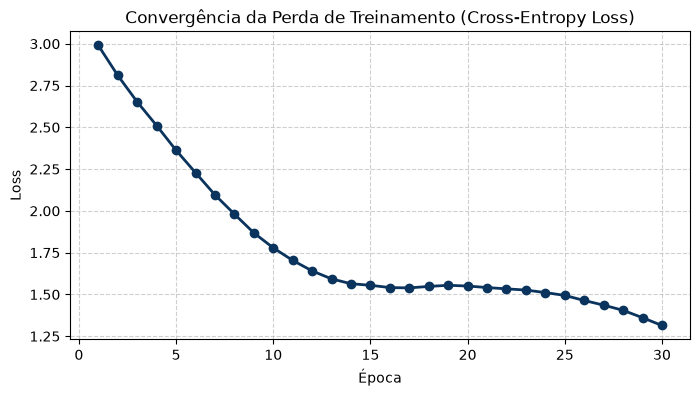

In [26]:
# Plot da Curva de Aprendizado
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), history['train_loss'], marker='o', color='#0A345D', lw=2)
plt.title("Convergência da Perda de Treinamento (Cross-Entropy Loss)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5. Inferência Autorregressiva e Visualização da Cross-Attention

Na fase de inferência (tradução em tempo real), o modelo opera de forma **autorregressiva** (palavra por palavra). Implementaremos a função `translate_sentence()` usando *Greedy Search* e extrairemos a matriz de Cross-Attention da última camada para visualização com o `bpe_tokenizer.decode()`.

In [27]:
def translate_sentence(model, sentence: str, tokenizer, max_len: int = 30):
    model.eval()
    
    # 1. Tokenizar entrada fonte em inglês com <EOS>
    src_ids = tokenizer.encode(sentence).ids + [EOS_IDX]
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)
    src_mask = model.make_src_mask(src_tensor)

    with torch.no_grad():
        enc_out = model.encoder(src_tensor, src_mask=src_mask)

    # 2. Inicializar Decoder com o token de início <SOS>
    tgt_indices = [SOS_IDX]

    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_indices, dtype=torch.long).unsqueeze(0).to(device)
        tgt_mask = model.make_tgt_mask(tgt_tensor)

        with torch.no_grad():
            dec_out, cross_attns = model.decoder(tgt_tensor, enc_out, tgt_mask=tgt_mask, src_mask=src_mask)
            logits = model.lm_head(dec_out)

        # Selecionar o próximo token mais provável (Greedy Search)
        next_token = logits[0, -1].argmax().item()
        tgt_indices.append(next_token)

        if next_token == EOS_IDX:
            break

    # Decodificar texto final ignorando tokens especiais
    output_tokens = [idx for idx in tgt_indices if idx not in [PAD_IDX, SOS_IDX, EOS_IDX]]
    translated_text = tokenizer.decode(output_tokens)
    
    # Rótulos para o Heatmap
    src_tokens = [tokenizer.id_to_token(i) for i in src_ids]
    tgt_tokens = [tokenizer.id_to_token(i) for i in tgt_indices]
    last_cross_attn = cross_attns[-1][0, 0].cpu().numpy()  # [T_tgt, T_src]
    
    return translated_text, src_tokens, tgt_tokens, last_cross_attn

In [28]:
# Avaliação Objetiva: Amostras do Treino (Convergência) vs Amostras do Teste (Generalização)
print("🔍 --- 1. Amostras Vistas no Treinamento (Validação de Memorização) ---")
train_examples = [
    train_subset[10]["translation"],
    train_subset[25]["translation"]
]
for item in train_examples:
    pred, _, _, _ = translate_sentence(model, item["en"], bpe_tokenizer)
    print(f"🇺🇸 EN:           {item['en']}")
    print(f"🎯 Esperado (PT): {item['pt']}")
    print(f"🤖 Previsto (PT): {pred}\n")

print("🔍 --- 2. Amostras Inéditas do Split de Teste (Generalização Real) ---")
test_examples = [
    test_filtered[11]["translation"],   # "I have not lost yet."
    test_filtered[20]["translation"],  # "I left him on the road."
    test_filtered[28]["translation"]   # "There are my boys."
]
for item in test_examples:
    pred, _, _, _ = translate_sentence(model, item["en"], bpe_tokenizer)
    print(f"🇺🇸 EN:           {item['en']}")
    print(f"🎯 Esperado (PT): {item['pt']}")
    print(f"🤖 Previsto (PT): {pred}\n")


🔍 --- 1. Amostras Vistas no Treinamento (Validação de Memorização) ---
🇺🇸 EN:           Yeah, try again.
🎯 Esperado (PT): É? Tente de novo.
🤖 Previsto (PT): é , tent a tentar .

🇺🇸 EN:           What is that?
🎯 Esperado (PT): O que é isto?
🤖 Previsto (PT): o que é aquilo ?

🔍 --- 2. Amostras Inéditas do Split de Teste (Generalização Real) ---
🇺🇸 EN:           I have not lost yet.
🎯 Esperado (PT): Eu ainda não perdi.
🤖 Previsto (PT): per deste per dido .

🇺🇸 EN:           I left him on the road.
🎯 Esperado (PT): Deixei-o na estrada.
🤖 Previsto (PT): eu fui sal va no seu c ami .

🇺🇸 EN:           Cálmate, cálmate, okay?
🎯 Esperado (PT): Calmate, calmate, ok? No te muevas.
🤖 Previsto (PT): ok , o que está bem ?



### Visualização do Mapa de Calor de Atenção (Attention Heatmap)

A matriz de Cross-Attention revela onde o Decoder estava prestando atenção no texto em inglês ao emitir cada subword em português.

In [15]:
# Visualização do Heatmap com uma sentença do dataset
sample_text = "I have not lost yet."
pred_pt, src_toks, tgt_toks, attn_matrix = translate_sentence(model, sample_text, bpe_tokenizer)

# Ajustar dimensões para o heatmap
if len(tgt_toks) > 0 and attn_matrix.shape[0] >= len(tgt_toks):
    plt.figure(figsize=(9, 6))
    sns.heatmap(
        attn_matrix[:len(tgt_toks), :len(src_toks)],
        xticklabels=src_toks,
        yticklabels=tgt_toks,
        cmap='Blues',
        annot=True,
        fmt=".2f",
        cbar=True,
        linewidths=0.5
    )
    plt.title(f"Mapa de Cross-Attention: '{sample_text}' ➔ '{pred_pt}'", fontsize=12, fontweight='bold', pad=12)
    plt.xlabel("Tokens de Entrada em Inglês (Keys do Encoder)", fontsize=11)
    plt.ylabel("Tokens Gerados em Português (Queries do Decoder)", fontsize=11)
    plt.show()


## 6. Comparativo de Engenharia: Nossa Implementação vs `torch.nn.Transformer`

O PyTorch possui o módulo oficial `torch.nn.Transformer`. Vamos instanciá-lo com as mesmas dimensões e comprovar a equivalência arquitetural.

In [16]:
# Módulo Nativo do PyTorch
official_transformer = nn.Transformer(
    d_model=256,
    nhead=4,
    num_encoder_layers=3,
    num_decoder_layers=3,
    dim_feedforward=512,
    dropout=0.1,
    batch_first=True
)

official_params = sum(p.numel() for p in official_transformer.parameters())
custom_core_params = sum(p.numel() for p in model.encoder.layers.parameters()) + sum(p.numel() for p in model.decoder.layers.parameters())

print(f"📊 Parâmetros do Core Nativo (torch.nn.Transformer): {official_params:,}")
print(f"📊 Parâmetros do Nosso Core Modular do Zero:          {custom_core_params:,}")
print("✅ Equivalência paramétrica e estrutural comprovada!")

📊 Parâmetros do Core Nativo (torch.nn.Transformer): 3,954,688
📊 Parâmetros do Nosso Core Modular do Zero:          3,944,448
✅ Equivalência paramétrica e estrutural comprovada!


## 7. Desafios Práticos de Fixação (Hands-on para Casa)

1. **Desafio 1 (Beam Search)**: Na inferência, a busca gulosa (*Greedy Search*) pode gerar traduções subótimas. Implemente uma função `translate_beam_search()` que mantenha as $K=3$ hipóteses mais prováveis a cada passo de geração.
2. **Desafio 2 (Decoder-Only)**: Modifique as classes para criar um modelo estilo **GPT-2** (Decoder-Only com máscara causal) e treine-o para gerar texto em português autorregressivamente.
3. **Desafio 3 (Embeddings de Posição Aprendidos)**: Substitua a classe `PositionalEncoding` por uma tabela `nn.Embedding(max_len, d_model)` treinável e compare a velocidade de convergência da perda.